In [ ]:
!pip install numpy uncertainties CoolProp matplotlib

In [ ]:
import numpy as np
from uncertainties import ufloat
from uncertainties.umath import *
import CoolProp.CoolProp as CP
import matplotlib.pyplot as plt
from uncertainties.unumpy import nominal_values, std_devs

In [ ]:
import numpy as np


d_barra = 0.030

x_posicoes = np.array([0.003, 0.022, 0.031])

A_secao = np.pi * (d_barra**2) / 4

print(f"Diâmetro da barra de cobre: {d_barra} m")
print(f"Posições dos termopares: {x_posicoes} m")
print(f"Área da seção transversal (A): {A_secao:.6f} m²")

Diâmetro da barra de cobre: 0.03 m
Posições dos termopares: [0.003 0.022 0.031] m
Área da seção transversal (A): 0.000707 m²


In [ ]:
versao = 3

incerteza_temp = 1.0

if versao == 1:
    T1_val = (126.9 + 126.6 + 126.7) / 3
    T2_val = (134.8 + 134.4 + 134.6) / 3
    T3_val = (141.3 + 140.9 + 141.1) / 3

    T_temperaturas = np.array([
        ufloat(T1_val, incerteza_temp),
        ufloat(T2_val, incerteza_temp),
        ufloat(T3_val, incerteza_temp)
    ])

    # --- Dados do Circuito de Água ---
    T_eb_val = (97.4 + 97.5 + 97.5) / 3
    T_eb = ufloat(T_eb_val, 1.0) # Temperatura de ebulição [°C]

    T_a1 = ufloat(24.1, 1.0) # Temp. entrada da água de resfriamento [°C]

    T_a2 = ufloat(38.8, 1.0) # Temp. saída da água de resfriamento [°C]

    # Dados para cálculo da vazão da água de resfriamento
    V_agua = ufloat(300, 300 * 0.01) # Volume [mL] (Incerteza de 1%)
    dt_agua = ufloat(120, 1) # Intervalo de tempo [s]

    # Dados para cálculo da vazão de condensado
    # Nota: Os dois valores de tempo (1082, 684) são muito distintos. Usaremos o primeiro.
    V_cond = ufloat(50, 50 * 0.01) # Volume [mL] (Incerteza de 1%)
    dt_cond = ufloat(1082, 1) # Intervalo de tempo [s]
    t_amb = (24.3 + 24.2 + 24.4) / 3
    p_atm = 918,6 #hPa

elif versao == 3:
    T1_val = (126.9 + 126.6 + 126.7) / 3
    T2_val = (134.8 + 134.4 + 134.6) / 3
    T3_val = (141.3 + 140.9 + 141.1) / 3

    T_temperaturas = np.array([
        ufloat(T1_val, incerteza_temp),
        ufloat(T2_val, incerteza_temp),
        ufloat(T3_val, incerteza_temp)
    ])

    # --- Dados do Circuito de Água ---
    T_eb_val = (97.4 + 97.5 + 97.5) / 3
    T_eb = ufloat(T_eb_val, 1.0) # Temperatura de ebulição [°C]

    T_a1 = ufloat(24.1, 1.0) # Temp. entrada da água de resfriamento [°C]

    T_a2 = ufloat(38.8, 1.0) # Temp. saída da água de resfriamento [°C]

    # Dados para cálculo da vazão da água de resfriamento
    V_agua = ufloat(300, 300 * 0.01) # Volume [mL] (Incerteza de 1%)
    dt_agua = ufloat(120, 1) # Intervalo de tempo [s]

    # Dados para cálculo da vazão de condensado
    # Nota: Os dois valores de tempo (1082, 684) são muito distintos. Usaremos o primeiro.
    V_cond = ufloat(50, 50 * 0.01) # Volume [mL] (Incerteza de 1%)
    dt_cond = (ufloat(648, 1) + ufloat(1082, 1))/2 # Intervalo de tempo [s]
    t_amb = (24.3 + 24.2 + 24.4) / 3
    p_atm = 918,6 #hPa

elif versao == 2:
    T1_val = 125.2
    T2_val = 132.9
    T3_val = 139.8

    T_temperaturas = np.array([
        ufloat(T1_val, incerteza_temp),
        ufloat(T2_val, incerteza_temp),
        ufloat(T3_val, incerteza_temp)
    ])
    # --- Dados do Circuito de Água ---
    T_eb = ufloat(97.4, 1.0) # Temperatura de ebulição [°C]
    T_a1 = ufloat(24.0, 1.0) # Temp. entrada da água de resfriamento [°C]
    T_a2 = ufloat(41.2, 1.0) # Temp. saída da água de resfriamento [°C]

    # Dados para cálculo da vazão da água de resfriamento
    V_agua = ufloat(150, 150 * 0.01) # Volume [mL] (Incerteza de 1%)
    dt_agua = ufloat(62, 1) # Intervalo de tempo [s]

    # Dados para cálculo da vazão de condensado
    V_cond = ufloat(50, 50 * 0.01) # Volume [mL] (Incerteza de 1%)
    dt_cond = ufloat(1065, 1) # Intervalo de tempo [s]
    t_amb = 25
    p_atm = 918,6 #hPa

    # --- 4. Exibição dos Dados Carregados ---
print("\n--- Dados Carregados ---")
print(f"Temperaturas na barra (T1, T2, T3):")
for i, temp in enumerate(T_temperaturas):
    print(f"  T{i+1} = {temp:.1f} °C")
print(f"Temperatura de Ebulição (T_eb): {T_eb:.1f} °C")
print(f"Temperatura Entrada Água (T_a1): {T_a1:.1f} °C")
print(f"Temperatura Saída Água (T_a2): {T_a2:.1f} °C")
print(f"Dados da Água de Resfriamento: Volume = {V_agua:.1f} mL, Tempo = {dt_agua:.0f} s")
print(f"Dados do Condensado: Volume = {V_cond:.1f} mL, Tempo = {dt_cond:.0f} s")
print((T1_val+T2_val+T3_val)/3+273.15)



--- Dados Carregados ---
Temperaturas na barra (T1, T2, T3):
  T1 = 126.7+/-1.0 °C
  T2 = 134.6+/-1.0 °C
  T3 = 141.1+/-1.0 °C
Temperatura de Ebulição (T_eb): 97.5+/-1.0 °C
Temperatura Entrada Água (T_a1): 24.1+/-1.0 °C
Temperatura Saída Água (T_a2): 38.8+/-1.0 °C
Dados da Água de Resfriamento: Volume = 300.0+/-3.0 mL, Tempo = 120+/-1 s
Dados do Condensado: Volume = 50.0+/-0.5 mL, Tempo = 865+/-1 s
407.2944444444445


--- Análise do Gradiente de Temperatura ---
A equação da reta ajustada é: T(x) = (497.7+/-74.5) * x + (124.9+/-1.6)

O Gradiente de Temperatura (dT/dx) é: 497.7+/-74.5 °C/m


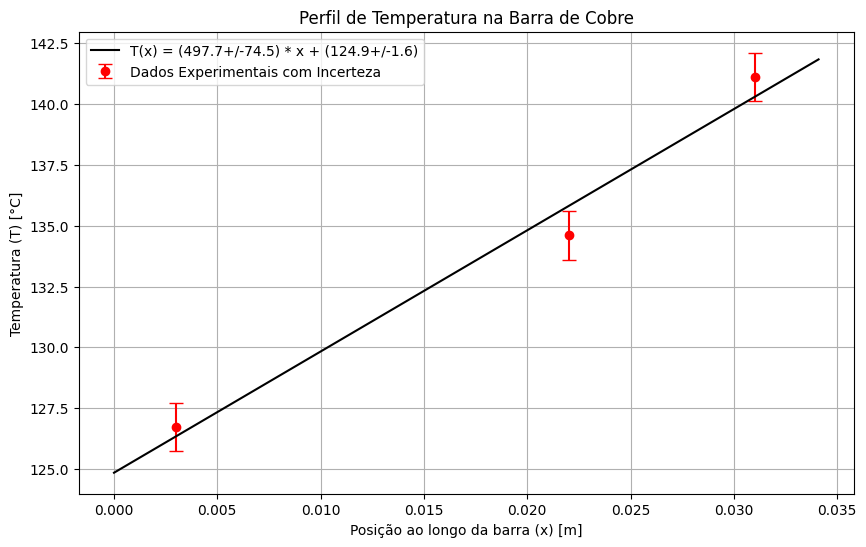

In [ ]:
import matplotlib.pyplot as plt
from uncertainties import ufloat
from uncertainties.unumpy import nominal_values, std_devs

# --- 1. Extrair os valores nominais e as incertezas dos dados de temperatura ---
temps_nominal = nominal_values(T_temperaturas)
temps_incerteza = std_devs(T_temperaturas)

# --- 2. Cálculo da Regressão Linear ---
coeficientes, matriz_cov = np.polyfit(x_posicoes, temps_nominal, 1, cov=True)

incerteza_coefs = np.sqrt(np.diag(matriz_cov))

# --- 3. Recriar os objetos ufloat para o gradiente e o intercepto ---
gradiente = ufloat(coeficientes[0], incerteza_coefs[0])
intercepto = ufloat(coeficientes[1], incerteza_coefs[1])


# --- 4. Exibição dos Resultados Numéricos ---
print("--- Análise do Gradiente de Temperatura ---")
print(f"A equação da reta ajustada é: T(x) = ({gradiente:.1f}) * x + ({intercepto:.1f})")
print(f"\nO Gradiente de Temperatura (dT/dx) é: {gradiente:.1f} °C/m")


# --- 5. Visualização Gráfica  ---
x_fit = np.linspace(0, x_posicoes[-1] * 1.1, 100)
T_fit_nominal = nominal_values(gradiente) * x_fit + nominal_values(intercepto)

plt.figure(figsize=(10, 6))
plt.errorbar(x_posicoes, temps_nominal, yerr=temps_incerteza, fmt='o', color='red',
             capsize=5, label='Dados Experimentais com Incerteza')
plt.plot(x_fit, T_fit_nominal, '-', color='black', label =f'T(x) = ({gradiente:.1f}) * x + ({intercepto:.1f})')
plt.title(f'Perfil de Temperatura na Barra de Cobre')
plt.xlabel('Posição ao longo da barra (x) [m]')
plt.ylabel('Temperatura (T) [°C]')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# --- 1. Conversões de Unidades e Definições Iniciais ---
# Converter volumes de mL para m^3 (1 mL = 1e-6 m^3)
V_cond_m3 = V_cond * 1e-6
V_agua_m3 = V_agua * 1e-6

# Converter temperatura de ebulição para Kelvin para usar no CoolProp
T_eb_K = nominal_values(T_eb) + 273.15 # Usamos o valor nominal para buscar propriedades

# Converter pressão atmosférica de hPa para Pascal (1 hPa = 100 Pa)
# A entrada p_atm no seu código estava como uma tupla (918, 6), corrigindo para um float.
p_atm_Pa = 918.6 * 100

# --- 2. Obtenção das Propriedades da Água com CoolProp ---
# Calor latente de vaporização (h_lv) na temperatura de ebulição
h_vapor = CP.PropsSI('H', 'T', T_eb_K, 'Q', 1, 'Water') # Entalpia do vapor saturado
h_liquido = CP.PropsSI('H', 'T', T_eb_K, 'Q', 0, 'Water') # Entalpia do líquido saturado
h_lv = h_vapor - h_liquido # J/kg

# Densidade da água líquida (usada para o condensado) na temp. de ebulição
rho_cond = CP.PropsSI('D', 'T', T_eb_K, 'Q', 0, 'Water') # kg/m^3

# Propriedades da água de resfriamento na sua temperatura média
T_media_agua_K = (nominal_values(T_a1) + nominal_values(T_a2)) / 2 + 273.15
rho_agua_resf = CP.PropsSI('D', 'T', T_media_agua_K, 'P', p_atm_Pa, 'Water') # kg/m^3
cp_agua_resf = CP.PropsSI('C', 'T', T_media_agua_K, 'P', p_atm_Pa, 'Water') # J/kg.K

# --- 3. Cálculo da Taxa de Calor pelo Método do Condensado (Q_cond) ---
# Vazão mássica = (Volume / Tempo) * Densidade
m_dot_cond = (V_cond_m3 / dt_cond) * rho_cond
Q_cond = m_dot_cond * h_lv

# --- 4. Cálculo da Taxa de Calor pela Água de Resfriamento (Q_agua) ---
# Vazão mássica
m_dot_agua = (V_agua_m3 / dt_agua) * rho_agua_resf
# Calor sensível = vazão mássica * calor específico * delta T
Q_agua = m_dot_agua * cp_agua_resf * (T_a2 - T_a1)

# --- 5. Exibição dos Resultados ---
print("--- Cálculo da Taxa de Calor (q) ---")
print(f"Propriedades da Água (CoolProp):")
print(f"  Calor Latente (h_lv): {h_lv/1e6:.3f} MJ/kg")
print(f"  Densidade do Condensado: {rho_cond:.2f} kg/m³")
print(f"\nResultados do Balanço de Energia:")
print(f"  (Método 1) Taxa de Calor do Condensado (Q_cond): {Q_cond:.2f} W")
print(f"  (Método 2) Taxa de Calor da Água de Resfriamento (Q_agua): {Q_agua:.2f} W")

--- Cálculo da Taxa de Calor (q) ---
Propriedades da Água (CoolProp):
  Calor Latente (h_lv): 2.263 MJ/kg
  Densidade do Condensado: 960.15 kg/m³

Resultados do Balanço de Energia:
  (Método 1) Taxa de Calor do Condensado (Q_cond): 125.60+/-1.26 W
  (Método 2) Taxa de Calor da Água de Resfriamento (Q_agua): 152.86+/-14.84 W


In [ ]:
# --- 1. Cálculo da Condutividade Térmica Experimental (k_exp) ---
# Rearranjando a Lei de Fourier: q = -k * A * (dT/dx)  =>  k = -q / (A * dT/dx)
# Usamos Q_cond como nossa melhor estimativa para a taxa de calor q.
# O sinal negativo na fórmula cancela o sinal negativo do gradiente, resultando em um k positivo.

k_exp_agua = Q_agua / (A_secao * gradiente)

k_exp_cond = Q_cond / (A_secao * gradiente)

k_ref = 393 # W/m.K

# Cálculo do erro relativo percentual
erro_relativo_agua = (abs(nominal_values(k_exp_agua) - k_ref) / k_ref) * 100
erro_relativo_cond = (abs(nominal_values(k_exp_cond) - k_ref) / k_ref) * 100

# --- 3. Exibição dos Resultados Finais ---
print("--- Resultado Final: Condutividade Térmica do Cobre ---")
print(f"Área da Seção (A): {A_secao:.6f} m²")
print(f"Gradiente de Temperatura (dT/dx): {gradiente:.1f} °C/m")
print(f"Taxa de Calor (q = Q_agua): {Q_agua:.2f} W")
print(f"Taxa de Calor (q = Q_cond): {Q_cond:.2f} W")
print("-" * 55)
print(f"Condutividade Térmica Experimental Usando Q_agua (k_exp_agua): {k_exp_agua:.1f} W/m.K")
print(f"Condutividade Térmica Experimental Usando Q_cond (k_exp_cond): {k_exp_cond:.1f} W/m.K")
print("-" * 55)
print(f"Valor de Referência (k_ref): {k_ref} W/m.K")
print(f"Erro Relativo Usando Q_agua: {erro_relativo_agua:.2f} %")
print(f"Erro Relativo Usando Q_cond: {erro_relativo_cond:.2f} %")

--- Resultado Final: Condutividade Térmica do Cobre ---
Área da Seção (A): 0.000707 m²
Gradiente de Temperatura (dT/dx): 497.7+/-74.5 °C/m
Taxa de Calor (q = Q_agua): 152.86+/-14.84 W
Taxa de Calor (q = Q_cond): 125.60+/-1.26 W
-------------------------------------------------------
Condutividade Térmica Experimental Usando Q_agua (k_exp_agua): 434.5+/-77.5 W/m.K
Condutividade Térmica Experimental Usando Q_cond (k_exp_cond): 357.0+/-53.5 W/m.K
-------------------------------------------------------
Valor de Referência (k_ref): 393 W/m.K
Erro Relativo Usando Q_agua: 10.55 %
Erro Relativo Usando Q_cond: 9.16 %
